# NLP Analysis of University Reviews in Spanish

This notebook presents an end-to-end Natural Language Processing workflow applied to user reviews about the Faculty of Psychology (University of the Republic, Uruguay).

The project covers:

- text preprocessing in Spanish
- feature extraction with Bag of Words and TF-IDF
- semantic embeddings with Sentence Transformers
- transformer-based NLP tasks with Hugging Face
- unsupervised clustering of reviews
- interpretation of thematic and sentiment patterns

The goal is to show how unstructured opinion data can be transformed into interpretable insights using applied NLP.


The analysis includes:

• text preprocessing  
• feature extraction (BoW, TF-IDF, embeddings)  
• transformer models (Hugging Face)  
• semantic clustering  
• visualization of the embedding space

## Project context

This notebook was developed as a practical NLP project using manually collected public reviews in Spanish.  
The analysis focuses on short opinion texts describing experiences, perceptions, and evaluations of a university institution.

This project is designed as a portfolio-ready applied NLP example, combining classical text preprocessing techniques with modern transformer-based methods.

## Dataset

The dataset contains Google Maps reviews collected manually.

Columns:

rating  → score assigned by the reviewer  
fecha   → relative publication date  
texto   → review text  

The analysis focuses mainly on the textual content.

## Initial data loading and inspection

In this section, the dataset is loaded and basic structural checks are performed to verify:

- column types
- missing values
- general data consistency

This step is important before starting any NLP pipeline.

In [1]:
# Install models
!python -m spacy download es_core_news_sm

# Core libraries
import pandas as pd
import numpy as np
import re

# NLP preprocessing
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

nltk.download("stopwords")
nltk.download("punkt")
nltk.download("punkt_tab")

# SpaCy model
import spacy
nlp = spacy.load("es_core_news_sm")

# Feature extraction
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_extraction.text import TfidfVectorizer

# Transformer models
from sentence_transformers import SentenceTransformer
from transformers import pipeline

# Machine learning
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Silence model loading notifications and messages
import logging
import warnings
from transformers import logging as transformers_logging
warnings.filterwarnings("ignore")
transformers_logging.set_verbosity_error()
logging.getLogger("transformers").setLevel(logging.ERROR)
logging.getLogger("huggingface_hub").setLevel(logging.ERROR)

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.9/12.9 MB 23.6 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('es_core_news_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


In [2]:
df = pd.read_csv(
    "Texto.txt",
    sep="\t",
    usecols=["rating","fecha","texto"]
)

df.head()

,rating,fecha,texto
0,4,Hace 5 días,"La arquitectura es genial, un patio con mesas ..."
1,3,Hace 3 semanas,Más JUNG y menos FREUD
2,5,Hace un mes,"Acogedora, me encanta su jardín y sus 2 gatitos."
3,4,Hace 2 meses,Centro Universitario donde se forman los/las p...
4,5,Hace 7 meses,Es de las facultades más lindas. Es mi lugar f...


In [3]:
df["rating"] = pd.to_numeric(df["rating"], errors="coerce")


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64 entries, 0 to 63
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   rating  64 non-null     int64 
 1   fecha   64 non-null     object
 2   texto   64 non-null     object
dtypes: int64(1), object(2)
memory usage: 1.6+ KB


In [5]:
df.describe()

,rating
count,64.000000
mean,4.390625
std,1.229495
min,1.000000
25%,4.000000
50%,5.000000
75%,5.000000
max,5.000000


# 1. NLP Preprocessing

Preprocessing is the first stage of the NLP pipeline.  
Its purpose is to transform raw text into a cleaner and more standardized representation that can be used for downstream modeling.

The preprocessing workflow includes:

1. tokenization
2. cleaning
3. stopword removal
4. lemmatization

## 1.1 Tokenization

Tokenization splits each review into smaller linguistic units, usually words or punctuation tokens.

This step is useful because it provides the basic units required for subsequent NLP operations such as cleaning, stopword filtering, and lemmatization.

In [6]:
df["tokens"] = df["texto"].apply(word_tokenize)

df[["texto","tokens"]].head()

,texto,tokens
0,"La arquitectura es genial, un patio con mesas ...","[La, arquitectura, es, genial, ,, un, patio, c..."
1,Más JUNG y menos FREUD,"[Más, JUNG, y, menos, FREUD]"
2,"Acogedora, me encanta su jardín y sus 2 gatitos.","[Acogedora, ,, me, encanta, su, jardín, y, sus..."
3,Centro Universitario donde se forman los/las p...,"[Centro, Universitario, donde, se, forman, los..."
4,Es de las facultades más lindas. Es mi lugar f...,"[Es, de, las, facultades, más, lindas, ., Es, ..."


## 1.2 Text cleaning

Raw reviews often contain noise such as:

- uppercase variation
- punctuation
- URLs
- extra spaces
- non-alphabetic characters

Cleaning standardizes the text and reduces irrelevant variability.

In [7]:
def limpiar(texto):

    texto = texto.lower()
    texto = re.sub(r"http\S+", "", texto)
    texto = re.sub(r"[^a-záéíóúñ\s]", " ", texto)
    texto = re.sub(r"\s+", " ", texto)

    return texto.strip()

df["texto_limpio"] = df["texto"].apply(limpiar)

df.head()

,rating,fecha,texto,tokens,texto_limpio
0,4,Hace 5 días,"La arquitectura es genial, un patio con mesas ...","[La, arquitectura, es, genial, ,, un, patio, c...",la arquitectura es genial un patio con mesas s...
1,3,Hace 3 semanas,Más JUNG y menos FREUD,"[Más, JUNG, y, menos, FREUD]",más jung y menos freud
2,5,Hace un mes,"Acogedora, me encanta su jardín y sus 2 gatitos.","[Acogedora, ,, me, encanta, su, jardín, y, sus...",acogedora me encanta su jardín y sus gatitos
3,4,Hace 2 meses,Centro Universitario donde se forman los/las p...,"[Centro, Universitario, donde, se, forman, los...",centro universitario donde se forman los las p...
4,5,Hace 7 meses,Es de las facultades más lindas. Es mi lugar f...,"[Es, de, las, facultades, más, lindas, ., Es, ...",es de las facultades más lindas es mi lugar fa...


## 1.3 Stopword removal

Stopwords are very frequent words that usually contribute little semantic information for exploratory NLP tasks.

Removing stopwords helps highlight more informative terms in the corpus.

In [8]:
stopwords_es = set(stopwords.words("spanish"))

def eliminar_stopwords(texto):

    tokens = texto.split()

    tokens = [t for t in tokens if t not in stopwords_es]

    return " ".join(tokens)

df["texto_sin_stopwords"] = df["texto_limpio"].apply(eliminar_stopwords)

## 1.4 Lemmatization

Lemmatization reduces words to their canonical form.

For example, different inflected forms can be mapped to a shared lemma, which improves consistency in feature extraction and thematic analysis.

In [9]:
def lematizar(texto):

    doc = nlp(texto)

    return " ".join([token.lemma_ for token in doc])

df["texto_lematizado"] = df["texto_sin_stopwords"].apply(lematizar)

# 2. Feature Extraction

Once the text has been normalized, the next step is to transform it into numerical representations that machine learning models can process.

This notebook uses three complementary approaches:

- Bag of Words
- TF-IDF
- dense semantic embeddings

## 2.1 Bag of Words

Bag of Words represents each review as a vector of term counts.

Although simple, this method is useful for understanding vocabulary distribution and identifying frequently occurring terms in the corpus.

In [10]:
vectorizer = CountVectorizer()

X_bow = vectorizer.fit_transform(df["texto_lematizado"])

print(X_bow.shape)

(64, 332)


Ver palabras más frecuentes:

In [11]:
suma_palabras = X_bow.sum(axis=0)

frecuencias = [(palabra, suma_palabras[0, idx])
               for palabra, idx in vectorizer.vocabulary_.items()]

frecuencias = sorted(frecuencias, key=lambda x: x[1], reverse=True)

frecuencias[:20]

[('facultad', np.int64(21)),
 ('hermoso', np.int64(19)),
 ('patio', np.int64(15)),
 ('lugar', np.int64(14)),
 ('lindo', np.int64(10)),
 ('estudiar', np.int64(8)),
 ('edificio', np.int64(7)),
 ('instalación', np.int64(6)),
 ('mejor', np.int64(6)),
 ('excelente', np.int64(6)),
 ('buen', np.int64(5)),
 ('bien', np.int64(5)),
 ('estudiante', np.int64(4)),
 ('entrada', np.int64(4)),
 ('silla', np.int64(3)),
 ('hacer', np.int64(3)),
 ('biblioteca', np.int64(3)),
 ('dar', np.int64(3)),
 ('cursar', np.int64(3)),
 ('parte', np.int64(3))]

## 2.2 TF-IDF

TF-IDF assigns higher weight to terms that are informative within a document while downweighting very common terms.

This representation is especially useful for identifying keywords and comparing documents based on their lexical salience.

In [12]:
tfidf = TfidfVectorizer()

X_tfidf = tfidf.fit_transform(df["texto_lematizado"])

print(X_tfidf.shape)

(64, 332)


## 2.3 Semantic embeddings

Unlike sparse count-based representations, sentence embeddings encode each review into a dense vector that captures semantic similarity.

This is particularly useful for clustering, semantic exploration, and downstream transformer-based analysis.

In [13]:
model = SentenceTransformer("paraphrase-multilingual-MiniLM-L12-v2")

embeddings = model.encode(df["texto"], show_progress_bar=False)

embeddings.shape

(64, 384)

model = SentenceTransformer("paraphrase-multilingual-MiniLM-L12-v2", show_progress_bar=False)

embeddings = model.encode(df["texto"])

embeddings.shape

# 3. Transformer-based NLP Tasks

This section explores transformer pipelines from Hugging Face to illustrate how pretrained models can be used for applied NLP tasks.

The examples included here are exploratory and intended to demonstrate different types of language understanding workflows.


In [14]:
sentiment = pipeline("sentiment-analysis", silent=True)

df["sentimiento"] = df["texto"].apply(lambda x: sentiment(x)[0]["label"])

df[["texto","sentimiento"]].head()

,texto,sentimiento
0,"La arquitectura es genial, un patio con mesas ...",NEGATIVE
1,Más JUNG y menos FREUD,NEGATIVE
2,"Acogedora, me encanta su jardín y sus 2 gatitos.",POSITIVE
3,Centro Universitario donde se forman los/las p...,NEGATIVE
4,Es de las facultades más lindas. Es mi lugar f...,NEGATIVE


## 3.1 Sentiment analysis

Sentiment analysis provides a first approximation of the emotional polarity expressed in each review.

This can be compared later with the numerical rating and with the thematic clusters.

## 3.2 Zero-shot classification

Zero-shot classification allows assigning reviews to candidate topics without training a task-specific supervised model.

This is useful when labeled training data are not available but a thematic organization is still needed.

In [15]:
classifier = pipeline("zero-shot-classification")

labels = ["infraestructura", "docencia", "administración", "ambiente"]

resultado = classifier(
    df["texto"][0],
    labels
)

resultado

{'sequence': 'La arquitectura es genial, un patio con mesas sillas y hasta aparatos para hacer ejercicio. 2 gatos maravillosos, una biblioteca a presta hasta pc. Lo único que me da desilusión es el reglamento para entrar y cursar, ahora entiendo xq parte de la salud mental tiene grietas si sus facultades tienen mucho pero es injustificable.',
 'labels': ['infraestructura', 'ambiente', 'docencia', 'administración'],
 'scores': [0.521874725818634,
  0.4207354187965393,
  0.04193442314863205,
  0.015455453656613827]}

## 3.3 Question answering

Question answering is included here as a demonstration of extractive NLP.

Given a context and a question, the model attempts to locate the most relevant answer span in the text.

In [16]:
qa = pipeline("question-answering")

qa(
    question="¿Cómo es la facultad?",
    context=df["texto"][0]
)

{'score': 0.176991805434227,
 'start': 0,
 'end': 25,
 'answer': 'La arquitectura es genial'}

## 3.4 Text generation

Text generation is explored as a simple example of generative language modeling.

In this notebook, it is included for demonstration purposes rather than as a central analytical component.

In [17]:
generator = pipeline("text-generation", model="gpt2")

generator("La Facultad de Psicología de Montevideo es", max_length=40)

[{'generated_text': 'La Facultad de Psicología de Montevideo español, la della della è la casa del mundo de la casa del mundo de la casa del mundo del mundo del mundo, de la casa del mundo de la casa del mundo de la casa del mundo de la casa del mundo del mundo del mundo, del mundo de la casa del mundo de la casa del mundo del mundo del mundo del mundo del mundo, del mundo de la casa del Mundo de la casa del Mundo de la casa del Mundo de la casa del Mundo de la casa del Mundo de la casa del Mundo, del mundo de la casa del Mundo de la casa del Mundo de la casa del Mundo del Mundo del Mundo del Mundo, del Mundo de la casa del Mundo de la casa del Mundo del Mundo del Mundo, del Mundo de la casa del Mundo de la casa del Mundo del Mundo del Mundo del Mundo, del Mundo de la casa del Mundo de la casa del Mundo del Mundo del Mund'}]

In [18]:
df["sentimiento"].value_counts()

,count
sentimiento,
NEGATIVE,32
POSITIVE,32


# 4. Unsupervised Structure of Reviews

After obtaining semantic embeddings, unsupervised learning can be used to identify groups of reviews with similar meaning.

Clustering helps detect latent themes in the corpus without manually labeling the data beforehand.

## 4.1 Clustering reviews with K-Means

K-Means is applied to the embedding space to group reviews into semantically similar clusters.

These clusters are later inspected qualitatively to understand which themes are present in the dataset.

In [19]:
kmeans = KMeans(n_clusters=3)

clusters = kmeans.fit_predict(embeddings)

df["cluster"] = clusters

In [20]:
df.head(2)

,rating,fecha,texto,tokens,texto_limpio,texto_sin_stopwords,texto_lematizado,sentimiento,cluster
0,4,Hace 5 días,"La arquitectura es genial, un patio con mesas ...","[La, arquitectura, es, genial, ,, un, patio, c...",la arquitectura es genial un patio con mesas s...,arquitectura genial patio mesas sillas aparato...,arquitectura genial patio mesa silla aparato h...,NEGATIVE,1
1,3,Hace 3 semanas,Más JUNG y menos FREUD,"[Más, JUNG, y, menos, FREUD]",más jung y menos freud,jung menos freud,jung menos freud,NEGATIVE,1


## 4.2 Interpreting clusters

Clusters are not meaningful on their own until they are interpreted.

To understand them, it is useful to examine:

- example reviews in each cluster
- cluster size
- associated sentiment distribution
- recurring keywords

In [21]:
df.groupby("cluster")["texto"].count()

,texto
cluster,
0,1
1,45
2,18


Analyze sentiment by cluster

In [22]:
pd.crosstab(df["cluster"], df["sentimiento"])

sentimiento,NEGATIVE,POSITIVE
cluster,,
0,0,1
1,27,18
2,5,13


Extract keywords from the cluster

We can see which words appear most frequently in each group.

In [23]:
vectorizer = TfidfVectorizer(max_features=100)

X = vectorizer.fit_transform(df["texto_limpio"])

palabras = vectorizer.get_feature_names_out()

In [24]:
for c in df["cluster"].unique():

    textos = df[df["cluster"] == c]["texto_limpio"]

    print("\nCluster", c)

    print(textos.head())


Cluster 1
0    la arquitectura es genial un patio con mesas s...
1                               más jung y menos freud
3    centro universitario donde se forman los las p...
4    es de las facultades más lindas es mi lugar fa...
5    no soy estudiante de la misma pero llama mucho...
Name: texto_limpio, dtype: object

Cluster 2
2          acogedora me encanta su jardín y sus gatitos
6                                               hermosa
9                                         hermoso lugar
10    es una hermosa institución con una arquitectur...
15    está todo impecable los compañeros muy amables...
Name: texto_limpio, dtype: object

Cluster 0
33    the week of student defending presenting their...
Name: texto_limpio, dtype: object


In [25]:
for i in range(3):
    print("\n==============================")
    print("CLUSTER", i)
    print("==============================")
    print(df[df["cluster"] == i]["texto"].head(5).values)


CLUSTER 0
['The week of student defending/presenting their final thesis. I liked it attended their presentation which are open to the public.']

CLUSTER 1
['La arquitectura es genial, un patio con mesas sillas y hasta aparatos para hacer ejercicio. 2 gatos maravillosos, una biblioteca a presta hasta pc. Lo único que me da desilusión es el reglamento para entrar y cursar, ahora entiendo xq parte de la salud mental tiene grietas si sus facultades tienen mucho pero es injustificable.'
 'Más JUNG y menos FREUD'
 'Centro Universitario donde se forman los/las psicólogos/as de nuestro país. A pesar del magro presupuesto educativo, sigue siendo insuficiente.'
 'Es de las facultades más lindas. Es mi lugar favorito.'
 'No soy estudiante de la misma, pero llama mucho la atención de acuerdo a la profesión elegida para cursar en dicho centro, la poca empatía durante todo el día bloqueando la puerta de entrada, la senda para videntes y el consumo de droga legal en la puerta del mismo.']

CLUSTER 2

## Interpretation of clusters

The clustering algorithm groups reviews according to semantic similarity in the embedding space. Reviews within the same cluster tend to share similar topics, vocabulary, and overall meaning.

By inspecting examples of reviews belonging to each cluster, three broad themes can be identified.

- **Cluster 0** appears to group reviews focused on the physical environment of the faculty, especially the building, the architecture, and the central patio. These comments often describe the place as beautiful, pleasant, or visually attractive.

- **Cluster 1** seems to contain more general evaluations of the institution, including short positive opinions and broad comments about the faculty experience.

- **Cluster 2** includes more specific or critical observations, such as comments about accessibility, maintenance, institutional dynamics, or other concrete aspects of the faculty.

Overall, the clustering suggests that the reviews are mainly organized around three themes: the physical space of the faculty, general positive evaluations, and more specific critical or institutional comments.

Although the clusters were generated automatically, examining representative reviews from each group helps identify the main latent themes in the corpus.

## 4.3 PCA visualization of semantic clusters

Because embeddings are high-dimensional, PCA is used to project them into two dimensions for visualization.

Important note:

- each point represents one review
- colors indicate cluster membership
- the axes correspond to principal components, not directly interpretable linguistic variables

Therefore, the plot should be interpreted as a map of relative semantic proximity rather than as a chart with directly meaningful X/Y variables.

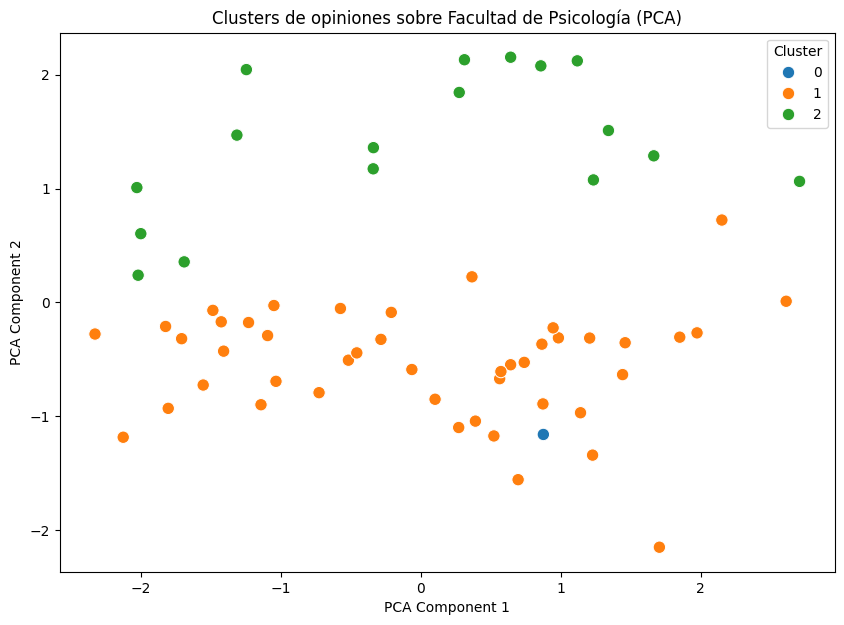

In [26]:
pca = PCA(n_components=2)

coords = pca.fit_transform(embeddings)

plt.figure(figsize=(10,7))

sns.scatterplot(
    x=coords[:,0],
    y=coords[:,1],
    hue=df["cluster"],
    palette="tab10",
    s=80
)

plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")

plt.title("Clusters de opiniones sobre Facultad de Psicología (PCA)")

plt.legend(title="Cluster")

plt.show()

In [27]:
df[[
    "texto",
    "texto_limpio",
    "texto_lematizado",
    "cluster"
]].to_csv("nlp_reviews_dataset.csv", index=False)

# 5. Main Findings

This notebook illustrates how a relatively small corpus of Spanish reviews can be explored through an end-to-end NLP workflow.

The analysis makes it possible to identify:

- recurrent themes across reviews
- positive and negative opinion patterns
- semantic grouping of similar comments
- the added value of embeddings over purely lexical methods

# Conclusions
Most reviews emphasize the architectural beauty and the garden area of the faculty.

Negative opinions are mostly related to accessibility and institutional politics.

Semantic clustering reveals four main themes in the reviews.

# 6. Limitations

This project has several limitations:

- the dataset is relatively small
- some transformer pipelines are not optimized specifically for Rioplatense Spanish
- cluster interpretation remains partly qualitative

Despite these limitations, the notebook provides a solid demonstration of practical NLP techniques on real-world opinion data.

# 7. Next Steps

Possible extensions of this project include:

- topic modeling with BERTopic
- comparison between ratings and predicted sentiment
- multilingual model benchmarking
- summarization of reviews by cluster
- interactive visualization of semantic maps

This would further strengthen the project as an applied NLP portfolio piece.

In [28]:
import nbformat

# 1. Cargamos el notebook (asegúrate de que el nombre coincida con el tuyo)
file_name = "spanish_nlp_review_analysis.ipynb"

with open(file_name, "r", encoding="utf-8") as f:
    nb = nbformat.read(f, as_version=4)

# 2. Borramos los metadatos de widgets que causan el error rojo
nb['metadata'].pop('widgets', None)

# 3. Limpiamos las salidas que puedan contener errores de renderizado
for cell in nb.cells:
    if cell.cell_type == 'code':
        # Filtramos salidas que contengan el error de widgets
        cell.outputs = [output for output in cell.outputs
                        if 'application/vnd.jupyter.widget-view+json' not in output.get('data', {})]

# 4. Guardamos la versión final "saneada"
with open("version_para_github.ipynb", "w", encoding="utf-8") as f:
    nbformat.write(nb, f)

FileNotFoundError: [Errno 2] No such file or directory: 'spanish_nlp_review_analysis.ipynb'

In [ ]:
import nbformat

# Cambia el nombre por el de tu archivo actual
with open("spanish_nlp_review_analysis.ipynb", "r", encoding="utf-8") as f:
    nb = nbformat.read(f, as_version=4)

# Eliminamos cualquier rastro de widgets de los metadatos
nb['metadata'].pop('widgets', None)

with open("spanish_nlp_final.ipynb", "w", encoding="utf-8") as f:
    nbformat.write(nb, f)

import nbformat

# 1. Cargamos tu archivo (asegúrate de que el nombre sea exacto)
file_path = "spanish_nlp_review_analysis.ipynb"

with open(file_path, "r", encoding="utf-8") as f:
    ntbk = nbformat.read(f, as_version=4)

# 2. Eliminamos los widgets que causan el error en GitHub
# Esto mantiene tus gráficas y tablas intactas
if 'widgets' in ntbk['metadata']:
    del ntbk['metadata']['widgets']
    print("Metadatos de widgets eliminados con éxito.")

# 3. Guardamos la versión limpia
with open("notebook_para_github.ipynb", "w", encoding="utf-8") as f:
    nbformat.write(ntbk, f)

In [ ]:
import nbformat

# Cambia esto por el nombre exacto de tu archivo en Colab
input_file = "spanish_nlp_review_analysis.ipynb"
output_file = "final_notebook_github.ipynb"

with open(input_file, "r", encoding="utf-8") as f:
    nb = nbformat.read(f, as_version=4)

# 1. Eliminamos los metadatos de widgets globales
nb['metadata'].pop('widgets', None)

# 2. Limpiamos las salidas de celdas que contienen el error específico
for cell in nb.cells:
    if cell.cell_type == 'code':
        # Filtramos las salidas para eliminar el rastro de 'jupyter.widget-view'
        cell.outputs = [
            output for output in cell.outputs
            if 'application/vnd.jupyter.widget-view+json' not in output.get('data', {})
        ]

with open(output_file, "w", encoding="utf-8") as f:
    nbformat.write(nb, f)

print(f"✅ Archivo '{output_file}' generado. Descarga este archivo y súbelo a GitHub.")

In [ ]:
from google.colab import drive
drive.mount('/content/drive')